# NSL-KDD HST — Explainability

---
## 1 — Setup & data loading

In [1]:
import os, json, csv, shutil, math, re, collections
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)
from scipy.stats import spearmanr
import lime
import lime.lime_tabular
import joblib

In [ ]:
# Paths
SCORES_FILE = r"C:\Users\Matilde\Documents\GitHub\tese\anomaly_scores_hst-nsl.csv"
TEST_PATH    = "NSL-KDD/KDDTest+.txt"
THRESHOLD    = 0.6120        

model = joblib.load("hst_model.pkl") 

C50_OUTDIR   = "c50_surrogate_results_hst"
LIME_OUTDIR  = "lime_results_hst"
os.makedirs(C50_OUTDIR, exist_ok=True)
os.makedirs(LIME_OUTDIR, exist_ok=True)

# Column names (KDD format)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins',
    'logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty'
]

In [ ]:
# Load anomaly scores
df = pd.read_csv(SCORES_FILE)
meta_cols    = ["index", "score", "y_true", "y_pred"]
feature_cols = [c for c in df.columns if c not in meta_cols]

# Load attack type labels from raw test file
def load_attack_labels(path):
    labels = []
    with open(path, 'r') as f:
        for row in csv.reader(f):
            if len(row) < len(columns):
                continue
            record = dict(zip(columns, row))
            labels.append(record['class'].strip().rstrip('.'))
    return labels

attack_labels = load_attack_labels(TEST_PATH)
df["attack_type"] = attack_labels[:len(df)]

# Categorical / numerical split
cat_cols = [c for c in feature_cols if df[c].dtype == object]
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f"Scores loaded  : {len(df)} rows")
print(f"Features       : {len(feature_cols)}  ({len(cat_cols)} categorical, {len(num_cols)} numerical)")
print(f"Attack types   : {df['attack_type'].nunique()}")
print(df['attack_type'].value_counts().head(15).to_string())

Scores loaded  : 22544 rows
Features       : 41  (3 categorical, 38 numerical)
Attack types   : 38
attack_type
normal           9711
neptune          4657
guess_passwd     1231
mscan             996
warezmaster       944
apache2           737
satan             735
processtable      685
smurf             665
back              359
snmpguess         331
saint             319
mailbomb          293
snmpgetattack     178
portsweep         157


---
## 2 — C5.0 global surrogate

In [4]:
TARGET_MODE  = "y_pred"
TEST_SIZE    = 0.3
RANDOM_STATE = 42

df["target_surrogate"] = df[TARGET_MODE].astype(str)
X = df[feature_cols].copy()
y = df["target_surrogate"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

train_df = X_train.copy()
train_df["target_surrogate"] = y_train.values
test_df  = X_test.copy()
test_df["target_surrogate"]  = y_test.values

train_df.to_csv(os.path.join(C50_OUTDIR, "c50_train.csv"), index=False)
test_df.to_csv( os.path.join(C50_OUTDIR, "c50_test.csv"),  index=False)

In [5]:
r_script = r'''
library(C50)

train_df <- read.csv("c50_surrogate_results_hst/c50_train.csv", stringsAsFactors=TRUE)
test_df  <- read.csv("c50_surrogate_results_hst/c50_test.csv",  stringsAsFactors=TRUE)

target_name <- "target_surrogate"
train_df[[target_name]] <- as.factor(train_df[[target_name]])
test_df[[target_name]]  <- as.factor(test_df[[target_name]])

for (col in names(train_df)) {
  if (is.factor(train_df[[col]]) && col != target_name) {
    test_df[[col]] <- factor(test_df[[col]], levels=levels(train_df[[col]]))
  }
}

x_train <- subset(train_df, select=-c(target_surrogate))
y_train <- train_df[[target_name]]
x_test  <- subset(test_df,  select=-c(target_surrogate))
y_test  <- test_df[[target_name]]

model_tree  <- C5.0(x_train, y_train, trials=1, rules=FALSE)
model_rules <- C5.0(x_train, y_train, trials=1, rules=TRUE)

pred <- predict(model_tree, x_test)

write.csv(
  data.frame(y_true=y_test, y_pred=pred),
  "c50_surrogate_results_hst/c50_predictions.csv",
  row.names=FALSE
)

capture.output(summary(model_tree),  file="c50_surrogate_results_hst/c50_summary.txt")
capture.output(model_tree,           file="c50_surrogate_results_hst/c50_tree.txt")
capture.output(summary(model_rules), file="c50_surrogate_results_hst/c50_rules.txt")

imp_usage  <- C5imp(model_tree, metric="usage")
imp_splits <- C5imp(model_tree, metric="splits")

imp_df <- data.frame(
  feature = row.names(imp_usage),
  usage   = imp_usage[,1],
  splits  = imp_splits[,1],
  row.names = NULL
)

write.csv(
  imp_df,
  "c50_surrogate_results_hst/c50_variable_importance.csv",
  row.names=FALSE
)

print(model_tree)
cat("\n--- Variable importance (usage) ---\n")
print(imp_df[order(-imp_df$usage),])
'''

with open("run_c50_global.R", "w", encoding="utf-8") as f:
    f.write(r_script)

rscript_path = shutil.which("Rscript")
if rscript_path is None:
    fallback = r"C:\Program Files\R\R-4.4.1\bin\x64\Rscript.exe"
    if os.path.exists(fallback):
        rscript_path = fallback
    else:
        raise FileNotFoundError("Rscript not found. Make sure R is installed and on PATH.")

result = subprocess.run([rscript_path, "run_c50_global.R"], capture_output=True, text=True)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)
else:
    print(result.stdout)


Call:
C5.0.default(x = x_train, y = y_train, trials = 1, rules = FALSE)

Classification Tree
Number of samples: 15780 
Number of predictors: 41 

Tree size: 86 

Non-standard options: attempt to group attributes


--- Variable importance (usage) ---
                       feature  usage    splits
1                    dst_bytes 100.00 13.580247
2  dst_host_same_src_port_rate  59.65  9.876543
3                protocol_type  53.69  8.641975
4                      service  52.33  4.938272
5           srv_diff_host_rate  48.32  4.938272
6               is_guest_login  47.67  4.938272
7                         flag  44.14  4.938272
8         dst_host_rerror_rate  42.38  4.938272
9                diff_srv_rate  41.83  4.938272
10        dst_host_serror_rate  41.79  3.703704
11                       count  40.24  3.703704
12                   srv_count  39.92  3.703704
13 dst_host_srv_diff_host_rate  39.28  3.703704
14             srv_rerror_rate  39.18  2.469136
15                  root_shel

In [ ]:
# C5.0 fidelity metrics
pred_df = pd.read_csv(os.path.join(C50_OUTDIR, "c50_predictions.csv"))

acc    = accuracy_score(pred_df["y_true"], pred_df["y_pred"])
report = classification_report(pred_df["y_true"], pred_df["y_pred"], output_dict=True)
cm     = confusion_matrix(pred_df["y_true"], pred_df["y_pred"])

metrics_obj = {"fidelity_accuracy": acc, "confusion_matrix": cm.tolist(), "report": report}
with open(os.path.join(C50_OUTDIR, "surrogate_metrics.json"), "w") as f:
    json.dump(metrics_obj, f, indent=2)

print(f"Fidelity accuracy : {acc:.4f}")
print(classification_report(pred_df["y_true"], pred_df["y_pred"]))

Fidelity accuracy : 0.9901
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2821
           1       0.99      0.99      0.99      3943

    accuracy                           0.99      6764
   macro avg       0.99      0.99      0.99      6764
weighted avg       0.99      0.99      0.99      6764



In [ ]:
# C5.0 global variable importance
c50_imp = pd.read_csv(os.path.join(C50_OUTDIR, "c50_variable_importance.csv"))
c50_imp = c50_imp.sort_values("usage", ascending=False).reset_index(drop=True)
c50_imp["usage_pct"]  = c50_imp["usage"]  / c50_imp["usage"].sum()  * 100
c50_imp["splits_pct"] = c50_imp["splits"] / c50_imp["splits"].sum() * 100
print(c50_imp.head(15).to_string(index=False))

                    feature  usage    splits  usage_pct  splits_pct
                  dst_bytes 100.00 13.580247  11.225486   13.580247
dst_host_same_src_port_rate  59.65  9.876543   6.696003    9.876543
              protocol_type  53.69  8.641975   6.026964    8.641975
                    service  52.33  4.938272   5.874297    4.938272
         srv_diff_host_rate  48.32  4.938272   5.424155    4.938272
             is_guest_login  47.67  4.938272   5.351189    4.938272
                       flag  44.14  4.938272   4.954930    4.938272
       dst_host_rerror_rate  42.38  4.938272   4.757361    4.938272
              diff_srv_rate  41.83  4.938272   4.695621    4.938272
       dst_host_serror_rate  41.79  3.703704   4.691131    3.703704
                      count  40.24  3.703704   4.517136    3.703704
                  srv_count  39.92  3.703704   4.481214    3.703704
dst_host_srv_diff_host_rate  39.28  3.703704   4.409371    3.703704
            srv_rerror_rate  39.18  2.469136   4

---
## 3 — LIME global importance

In [ ]:
# Numeric encoding for LIME explainer fit
X_lime_num = df[feature_cols].copy()
for col in cat_cols:
    X_lime_num[col] = pd.factorize(X_lime_num[col])[0].astype(float)

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime_num.values.astype(float),
    feature_names=feature_cols,
    class_names=["Normal", "Anomaly"],
    categorical_features=[feature_cols.index(c) for c in cat_cols],
    mode="classification",
    random_state=42
)

In [ ]:
# HST wrapper (feeds river model from numpy rows)
class HSTWrapper:
    def __init__(self, model, feature_names, cat_cols, num_cols):
        self.model    = model
        self.feat     = feature_names
        self.cat_set  = set(cat_cols)
        self.num_set  = set(num_cols)

    def predict_proba(self, X):
        probs = []
        for row in X:
            x_dict = {}
            for i, feat in enumerate(self.feat):
                val = row[i]
                x_dict[feat] = float(val) if feat in self.num_set else str(val)
            score = self.model.score_one(x_dict)
            probs.append([1 - score, score])
        return np.array(probs)

wrapper = HSTWrapper(model, feature_cols, cat_cols, num_cols)

In [ ]:
def extract_feature_name(lime_label, feature_cols):
    for col in sorted(feature_cols, key=len, reverse=True):
        if re.search(r'\b' + re.escape(col) + r'\b', lime_label):
            return col
    return None

N_GLOBAL = 1000

global_weights = collections.defaultdict(float)
sample_idx = df[df["y_pred"] == 1].index[:N_GLOBAL].tolist()

for idx in sample_idx:
    exp = explainer_lime.explain_instance(
        data_row=X_lime_num.values[idx],
        predict_fn=wrapper.predict_proba,
        num_features=len(feature_cols)
    )
    for feat, weight in exp.as_list():
        fname = extract_feature_name(feat, feature_cols)
        if fname:
            global_weights[fname] += abs(weight)

lime_global_imp = pd.DataFrame({
    "feature"         : list(global_weights.keys()),
    "mean_abs_weight" : [v / N_GLOBAL for v in global_weights.values()]
}).sort_values("mean_abs_weight", ascending=False).reset_index(drop=True)

lime_global_imp.to_csv(os.path.join(LIME_OUTDIR, "lime_global_importance.csv"), index=False)
print(lime_global_imp.head(15).to_string(index=False))

                 feature  mean_abs_weight
             rerror_rate         0.065203
          is_guest_login         0.055921
         srv_rerror_rate         0.043847
              root_shell         0.043594
           same_srv_rate         0.043519
          wrong_fragment         0.030466
         srv_serror_rate         0.028088
dst_host_srv_rerror_rate         0.026427
           is_host_login         0.026392
              num_shells         0.026336
                    land         0.025843
      srv_diff_host_rate         0.025256
           diff_srv_rate         0.024118
    dst_host_rerror_rate         0.022282
                  urgent         0.022017


---
## 4 — Global comparison: LIME vs C5.0

Compare the top-10 feature rankings from both methods and measure overlap.

In [11]:
TOP_N = 20 

top_c50  = set(c50_imp.head(TOP_N)["feature"].tolist())
top_lime = set(lime_global_imp.head(TOP_N)["feature"].tolist())

only_c50  = sorted(top_c50 - top_lime)
only_lime = sorted(top_lime - top_c50)
common    = sorted(top_c50 & top_lime)

print(f"Top-{TOP_N} overlap: {len(common)}/{TOP_N} features in common")
print(f"  Common    ({len(common)}): {common}")
print(f"  Only C5.0 ({len(only_c50)}): {only_c50}")
print(f"  Only LIME ({len(only_lime)}): {only_lime}")

all_feats  = list(top_c50 | top_lime)
ranks_c50  = {f: c50_imp[c50_imp["feature"]==f].index[0]+1
              if f in top_c50 else TOP_N+1 for f in all_feats}
ranks_lime = {f: lime_global_imp[lime_global_imp["feature"]==f].index[0]+1
              if f in top_lime else TOP_N+1 for f in all_feats}
vec_c50  = [ranks_c50[f]  for f in all_feats]
vec_lime = [ranks_lime[f] for f in all_feats]
rho, pval = spearmanr(vec_c50, vec_lime)
print(f"\nSpearman rank correlation (top-{TOP_N} union): rho={rho:.3f}  p={pval:.4f}")

overlap_summary = {
    "top_n": TOP_N, "common": common,
    "only_c50": only_c50, "only_lime": only_lime,
    "spearman_rho": round(rho, 4), "spearman_p": round(pval, 4)
}
with open(os.path.join(LIME_OUTDIR, "global_overlap.json"), "w") as f:
    json.dump(overlap_summary, f, indent=2)

Top-20 overlap: 9/20 features in common
  Common    (9): ['diff_srv_rate', 'dst_host_rerror_rate', 'dst_host_same_src_port_rate', 'is_guest_login', 'rerror_rate', 'root_shell', 'serror_rate', 'srv_diff_host_rate', 'srv_rerror_rate']
  Only C5.0 (11): ['count', 'dst_bytes', 'dst_host_diff_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'duration', 'flag', 'protocol_type', 'service', 'srv_count']
  Only LIME (11): ['dst_host_count', 'dst_host_srv_rerror_rate', 'dst_host_srv_serror_rate', 'is_host_login', 'land', 'num_shells', 'same_srv_rate', 'srv_serror_rate', 'su_attempted', 'urgent', 'wrong_fragment']

Spearman rank correlation (top-20 union): rho=-0.392  p=0.0294


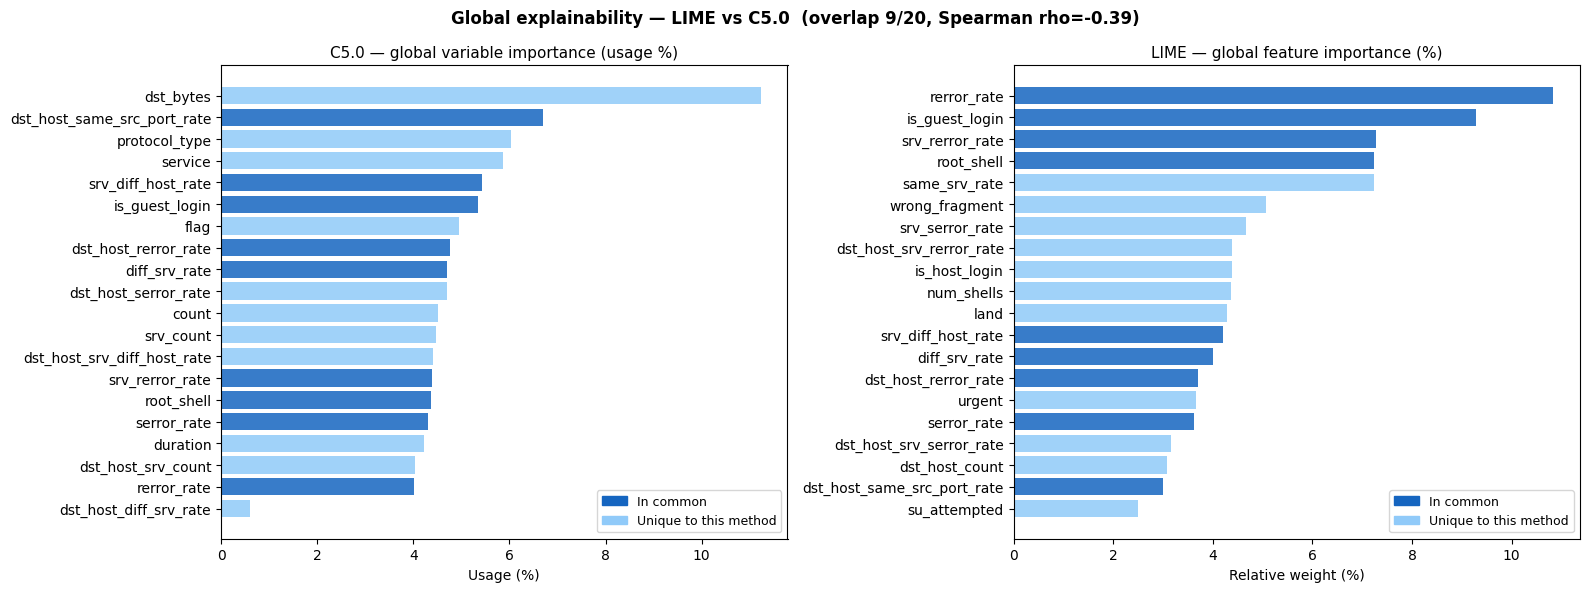

In [ ]:
# Side-by-side bar chart + overlap annotation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

c50_plot  = c50_imp.head(TOP_N).copy().sort_values("usage_pct")
lime_plot = lime_global_imp.head(TOP_N).copy()
lime_plot["pct"] = lime_plot["mean_abs_weight"] / lime_plot["mean_abs_weight"].sum() * 100
lime_plot = lime_plot.sort_values("pct")

for ax, data, col, title, xlabel in [
    (axes[0], c50_plot,  "usage_pct", "C5.0 — global variable importance (usage %)", "Usage (%)"),
    (axes[1], lime_plot, "pct",       "LIME — global feature importance (%)",        "Relative weight (%)"),
]:
    colors = ["#1565c0" if f in common else "#90caf9" for f in data["feature"]]
    ax.barh(data["feature"], data[col], color=colors, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    common_patch = mpatches.Patch(color="#1565c0", label="In common")
    unique_patch  = mpatches.Patch(color="#90caf9", label="Unique to this method")
    ax.legend(handles=[common_patch, unique_patch], fontsize=9)

plt.suptitle(
    f"Global explainability — LIME vs C5.0  "
    f"(overlap {len(common)}/{TOP_N}, Spearman rho={rho:.2f})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(LIME_OUTDIR, "global_lime_vs_c50.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5 — C5.0 importance per attack type

Train one C5.0 surrogate per attack type using examples of that type vs normal traffic.
This reveals which features drive the HST decision for each specific attack.

In [13]:
C50_PERTYPE_DIR = os.path.join(C50_OUTDIR, "per_attack_type")
os.makedirs(C50_PERTYPE_DIR, exist_ok=True)

attack_types = (
    df[df["attack_type"] != "normal"]["attack_type"]
    .value_counts()
    .index.tolist()
)
print(f"Attack types to process ({len(attack_types)}): {attack_types}")

Attack types to process (37): ['neptune', 'guess_passwd', 'mscan', 'warezmaster', 'apache2', 'satan', 'processtable', 'smurf', 'back', 'snmpguess', 'saint', 'mailbomb', 'snmpgetattack', 'portsweep', 'ipsweep', 'httptunnel', 'nmap', 'pod', 'buffer_overflow', 'multihop', 'named', 'ps', 'sendmail', 'rootkit', 'xterm', 'teardrop', 'xlock', 'land', 'xsnoop', 'ftp_write', 'worm', 'loadmodule', 'perl', 'sqlattack', 'udpstorm', 'phf', 'imap']


In [14]:
c50_per_type_imp = {}

for atype in attack_types:
    atype_dir = os.path.join(C50_PERTYPE_DIR, atype)
    atype_dir_r = atype_dir.replace("\\", "/")   # <- aqui, dentro do ciclo
    os.makedirs(atype_dir, exist_ok=True)

    sub = df[(df["attack_type"] == atype) | (df["attack_type"] == "normal")].copy()
    sub["target_surrogate"] = sub["y_pred"].astype(str)

    n_attack = (sub["attack_type"] == atype).sum()
    if n_attack < 2:
        print(f"[SKIP] {atype} — só {n_attack} instância(s), insuficiente para split")
        continue

    X_sub = sub[feature_cols]
    y_sub = sub["target_surrogate"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sub, y_sub, test_size=0.3, random_state=42, stratify=y_sub
    )

    tr_df = X_tr.copy()
    tr_df["target_surrogate"] = y_tr.values

    te_df = X_te.copy()
    te_df["target_surrogate"] = y_te.values

    tr_df.to_csv(os.path.join(atype_dir, "train.csv"), index=False)
    te_df.to_csv(os.path.join(atype_dir, "test.csv"), index=False)

    r_script = f'''
library(C50)

tr <- read.csv("{atype_dir_r}/train.csv", stringsAsFactors=TRUE)
te <- read.csv("{atype_dir_r}/test.csv", stringsAsFactors=TRUE)

tr$target_surrogate <- as.factor(tr$target_surrogate)
te$target_surrogate <- as.factor(te$target_surrogate)

for (col in names(tr)) {{
  if (is.factor(tr[[col]]) && col != "target_surrogate") {{
    te[[col]] <- factor(te[[col]], levels=levels(tr[[col]]))
  }}
}}

mod <- C5.0(subset(tr, select=-c(target_surrogate)), tr$target_surrogate, trials=1)
imp <- C5imp(mod, metric="usage")
imp_df <- data.frame(feature=row.names(imp), usage=imp[,1], row.names=NULL)
write.csv(imp_df, "{atype_dir_r}/importance.csv", row.names=FALSE)
'''

    rscript = os.path.join(atype_dir, "run.R")
    with open(rscript, "w", encoding="utf-8") as f:
        f.write(r_script)

    res = subprocess.run([rscript_path, rscript], capture_output=True, text=True)

    if res.returncode != 0:
        print(f"[ERROR] {atype}")
        print(res.stderr)
        continue

    imp_path = os.path.join(atype_dir, "importance.csv")
    if not os.path.exists(imp_path):
        print(f"[ERROR] {atype}: importance.csv não foi criado.")
        continue

    imp_df = pd.read_csv(imp_path)
    imp_df = imp_df.sort_values("usage", ascending=False).reset_index(drop=True)
    c50_per_type_imp[atype] = imp_df

    print(f"[OK] {atype}: {len(imp_df)} features")

print(f"\nDone — {len(c50_per_type_imp)} attack types processed.")

[OK] neptune: 41 features
[OK] guess_passwd: 41 features
[OK] mscan: 41 features
[OK] warezmaster: 41 features
[OK] apache2: 41 features
[OK] satan: 41 features
[OK] processtable: 41 features
[OK] smurf: 41 features
[OK] back: 41 features
[OK] snmpguess: 41 features
[OK] saint: 41 features
[OK] mailbomb: 41 features
[OK] snmpgetattack: 41 features
[OK] portsweep: 41 features
[OK] ipsweep: 41 features
[OK] httptunnel: 41 features
[OK] nmap: 41 features
[OK] pod: 41 features
[OK] buffer_overflow: 41 features
[OK] multihop: 41 features
[OK] named: 41 features
[OK] ps: 41 features
[OK] sendmail: 41 features
[OK] rootkit: 41 features
[OK] xterm: 41 features
[OK] teardrop: 41 features
[OK] xlock: 41 features
[OK] land: 41 features
[OK] xsnoop: 41 features
[OK] ftp_write: 41 features
[OK] worm: 41 features
[OK] loadmodule: 41 features
[OK] perl: 41 features
[OK] sqlattack: 41 features
[OK] udpstorm: 41 features
[OK] phf: 41 features
[SKIP] imap — só 1 instância(s), insuficiente para split

Do

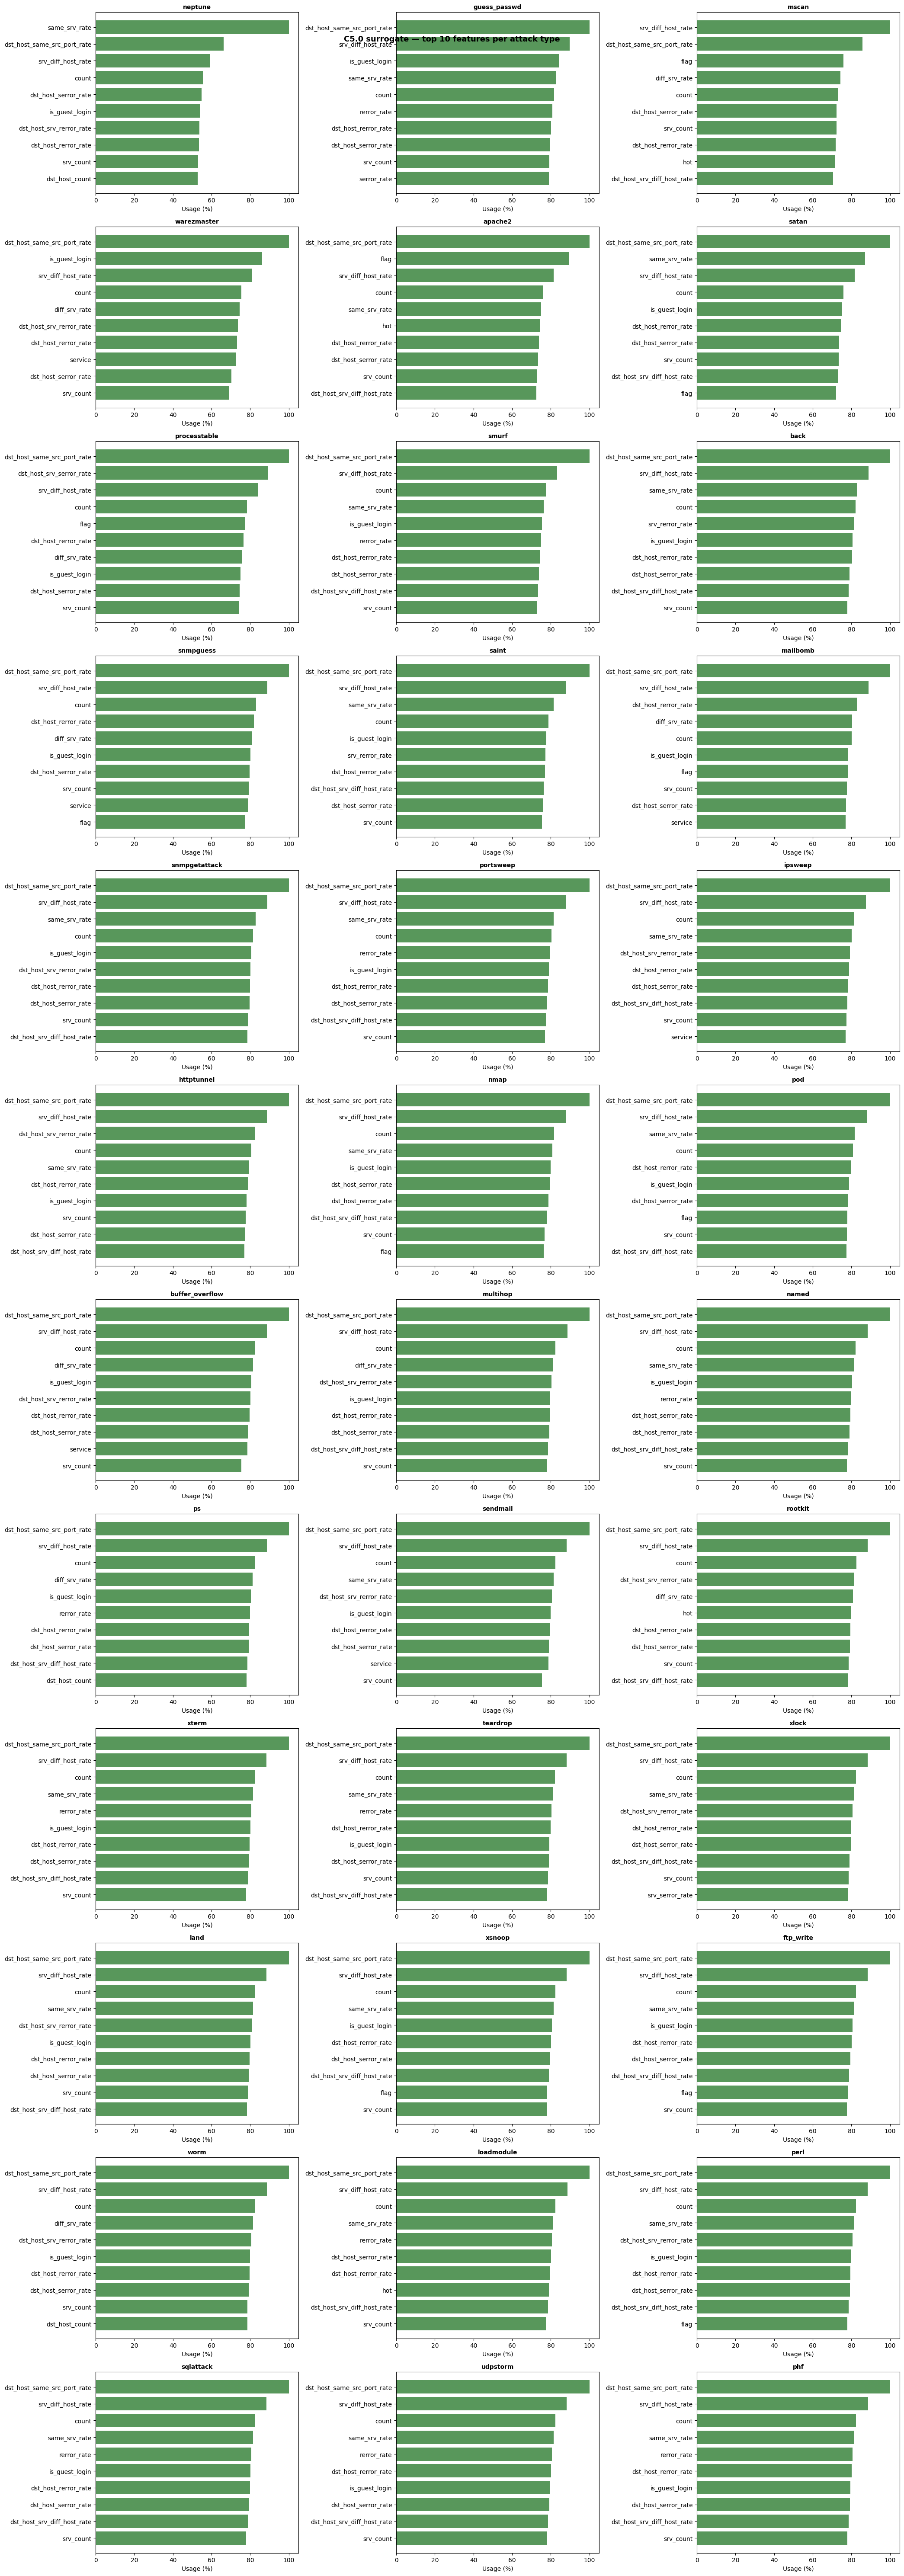

In [15]:
n_types = len(c50_per_type_imp)
n_cols  = min(3, n_types)
n_rows  = math.ceil(n_types / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for i, (atype, imp_df) in enumerate(c50_per_type_imp.items()):
    top5 = imp_df.head(10)
    axes[i].barh(top5["feature"][::-1], top5["usage"][::-1], color="#2e7d32", alpha=0.8)
    axes[i].set_title(f"{atype}", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Usage (%)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("C5.0 surrogate — top 10 features per attack type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(C50_OUTDIR, "c50_per_attack_type.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6 — LIME importance per attack type

In [ ]:
N_PER_TYPE = 500
lime_per_type_imp = {}

for atype in attack_types:
    positions = df[df["attack_type"     ] == atype].index.tolist()[:N_PER_TYPE]

    if len(positions) < 2:
        print(f"  [SKIP] {atype} — só {len(positions)} instância(s)")
        continue

    feat_weights = collections.defaultdict(float)
    for pos in positions:
        exp = explainer_lime.explain_instance(
            data_row=X_lime_num.values[pos],
            predict_fn=wrapper.predict_proba,
            num_features=len(feature_cols)
        )
        for feat, weight in exp.as_list():
            fname = extract_feature_name(feat, feature_cols)
            if fname:
                feat_weights[fname] += abs(weight)

    n = len(positions)
    lime_per_type_imp[atype] = pd.DataFrame({
        "feature"       : list(feat_weights.keys()),
        "avg_abs_weight": [v/n for v in feat_weights.values()]
    }).sort_values("avg_abs_weight", ascending=False).reset_index(drop=True)

    lime_per_type_imp[atype].to_csv(
        os.path.join(LIME_OUTDIR, f"lime_{atype}.csv"), index=False
    )
    print(f"  [OK] {atype}: {n} examples")

print(f"\nDone — {len(lime_per_type_imp)} attack types processed.")

  [OK] neptune: 500 examples
  [OK] guess_passwd: 500 examples
  [OK] mscan: 500 examples
  [OK] warezmaster: 500 examples
  [OK] apache2: 500 examples
  [OK] satan: 500 examples
  [OK] processtable: 500 examples
  [OK] smurf: 500 examples
  [OK] back: 359 examples
  [OK] snmpguess: 331 examples
  [OK] saint: 319 examples
  [OK] mailbomb: 293 examples
  [OK] snmpgetattack: 178 examples
  [OK] portsweep: 157 examples
  [OK] ipsweep: 141 examples
  [OK] httptunnel: 133 examples
  [OK] nmap: 73 examples
  [OK] pod: 41 examples
  [OK] buffer_overflow: 20 examples
  [OK] multihop: 18 examples
  [OK] named: 17 examples
  [OK] ps: 15 examples
  [OK] sendmail: 14 examples
  [OK] rootkit: 13 examples
  [OK] xterm: 13 examples
  [OK] teardrop: 12 examples
  [OK] xlock: 9 examples
  [OK] land: 7 examples
  [OK] xsnoop: 4 examples
  [OK] ftp_write: 3 examples
  [OK] worm: 2 examples
  [OK] loadmodule: 2 examples
  [OK] perl: 2 examples
  [OK] sqlattack: 2 examples
  [OK] udpstorm: 2 examples
  [OK

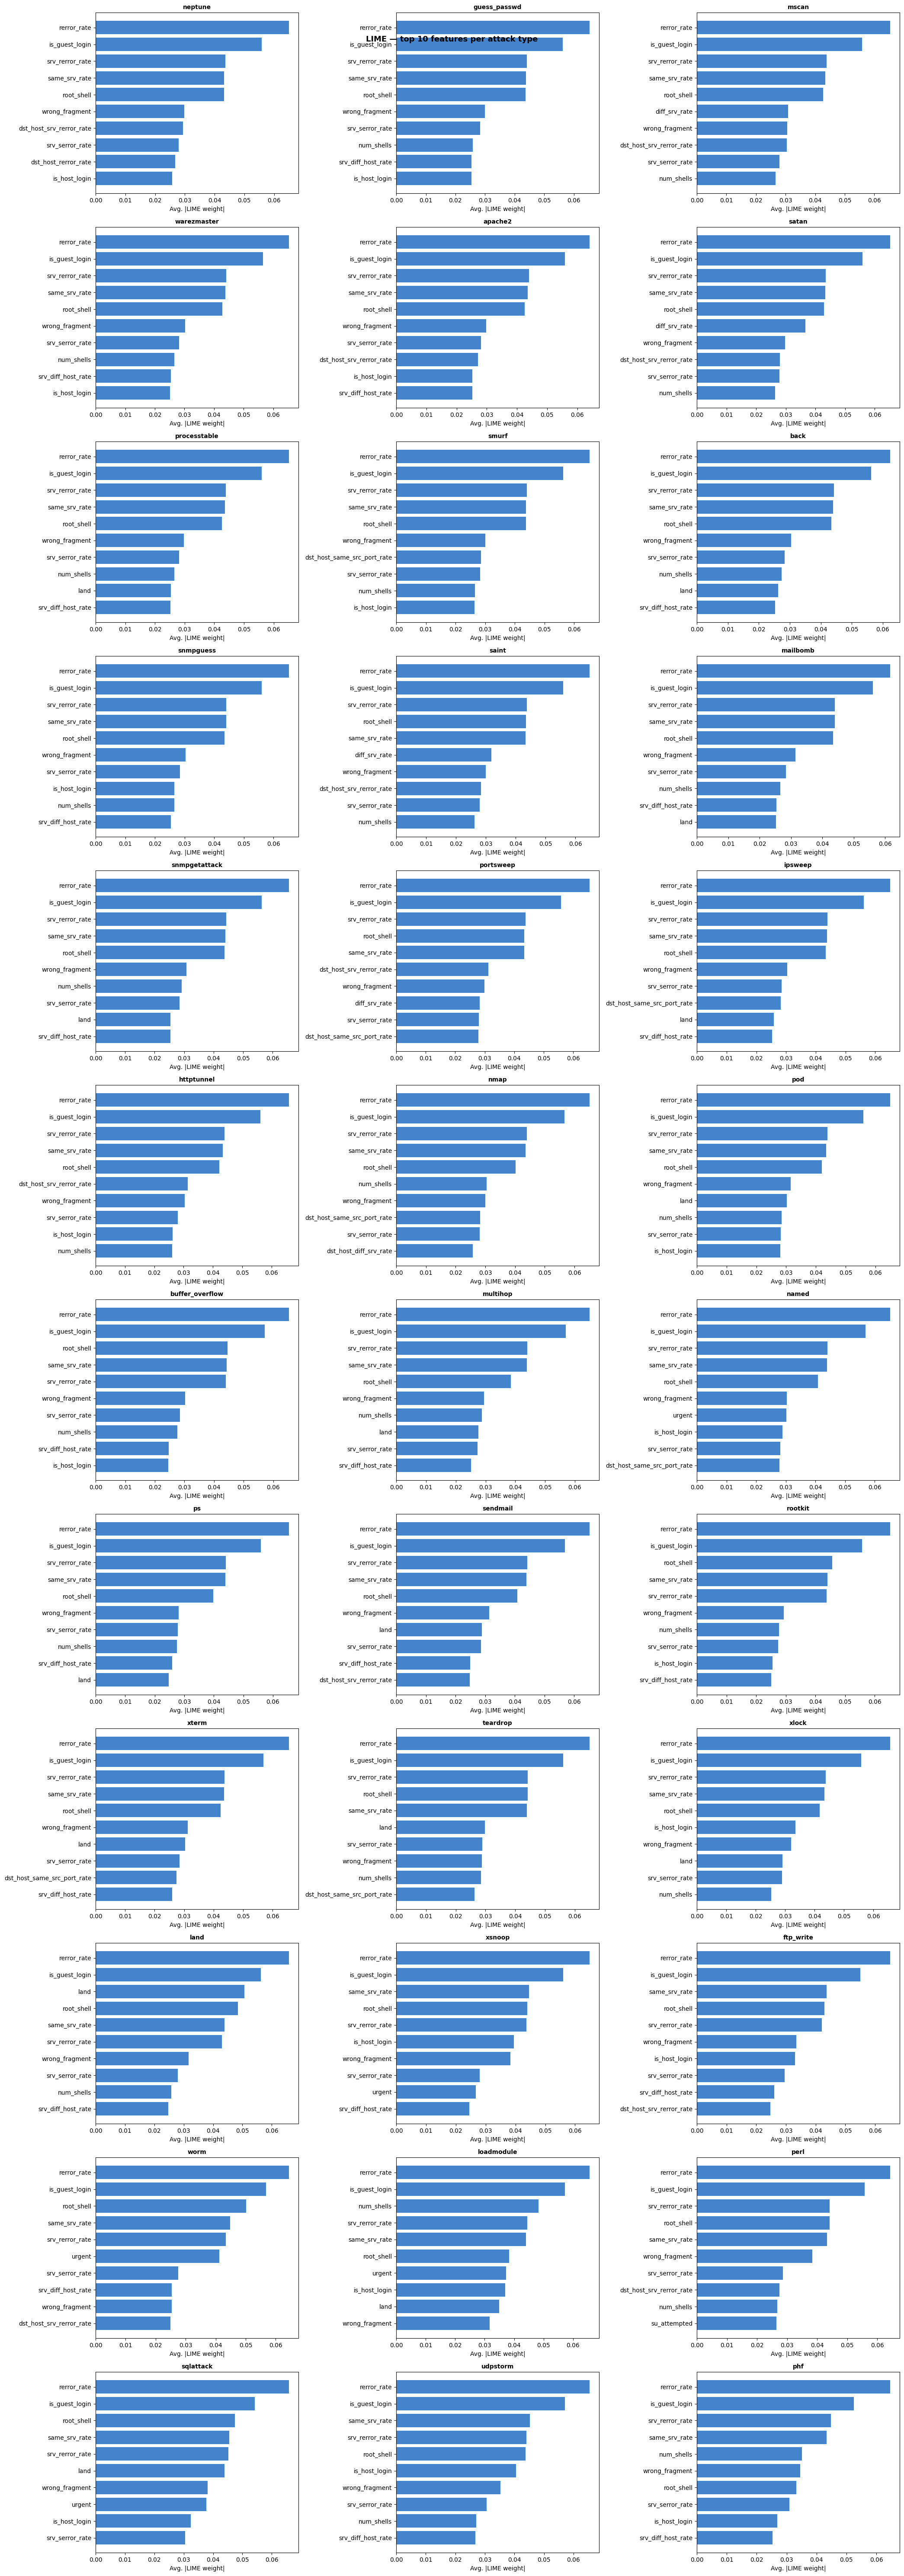

In [17]:
n_types = len(lime_per_type_imp)
n_cols  = min(3, n_types)
n_rows  = math.ceil(n_types / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for i, (atype, imp_df) in enumerate(lime_per_type_imp.items()):
    top5 = imp_df.head(10)
    axes[i].barh(top5["feature"][::-1], top5["avg_abs_weight"][::-1], color="#1565c0", alpha=0.8)
    axes[i].set_title(f"{atype}", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Avg. |LIME weight|")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("LIME — top 10 features per attack type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(LIME_OUTDIR, "lime_per_attack_type.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 7 — LIME vs C5.0 per attack type

In [18]:
TOP_K = 10
overlap_per_type = {}

common_types = sorted(set(lime_per_type_imp) & set(c50_per_type_imp))

for atype in common_types:
    top_lime_k = set(lime_per_type_imp[atype].head(TOP_K)["feature"])
    top_c50_k  = set(c50_per_type_imp[atype].head(TOP_K)["feature"])
    common_k   = top_lime_k & top_c50_k
    overlap_per_type[atype] = {
        "common"   : sorted(common_k),
        "only_lime": sorted(top_lime_k - top_c50_k),
        "only_c50" : sorted(top_c50_k - top_lime_k),
        "overlap_n": len(common_k)
    }

overlap_df = pd.DataFrame([
    {"attack_type": a, **d}
    for a, d in overlap_per_type.items()
])
overlap_df["common"] = overlap_df["common"].astype(str)
overlap_df["only_lime"] = overlap_df["only_lime"].astype(str)
overlap_df["only_c50"] = overlap_df["only_c50"].astype(str)

overlap_df.to_csv(os.path.join(LIME_OUTDIR, "overlap_per_attack_type.csv"), index=False)
print(overlap_df[["attack_type","overlap_n","common"]].to_string(index=False))

    attack_type  overlap_n                                                                                                  common
        apache2          2                                                                 ['same_srv_rate', 'srv_diff_host_rate']
           back          4                            ['is_guest_login', 'same_srv_rate', 'srv_diff_host_rate', 'srv_rerror_rate']
buffer_overflow          2                                                                ['is_guest_login', 'srv_diff_host_rate']
      ftp_write          3                                               ['is_guest_login', 'same_srv_rate', 'srv_diff_host_rate']
   guess_passwd          4                                ['is_guest_login', 'rerror_rate', 'same_srv_rate', 'srv_diff_host_rate']
     httptunnel          3                                         ['dst_host_srv_rerror_rate', 'is_guest_login', 'same_srv_rate']
        ipsweep          3                                  ['dst_host_same_src_por

---
## 8 — TP / FP analysis per attack type

C:\Users\Matilde\AppData\Local\Temp\ipykernel_16920\3773237915.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap(cmap_green)


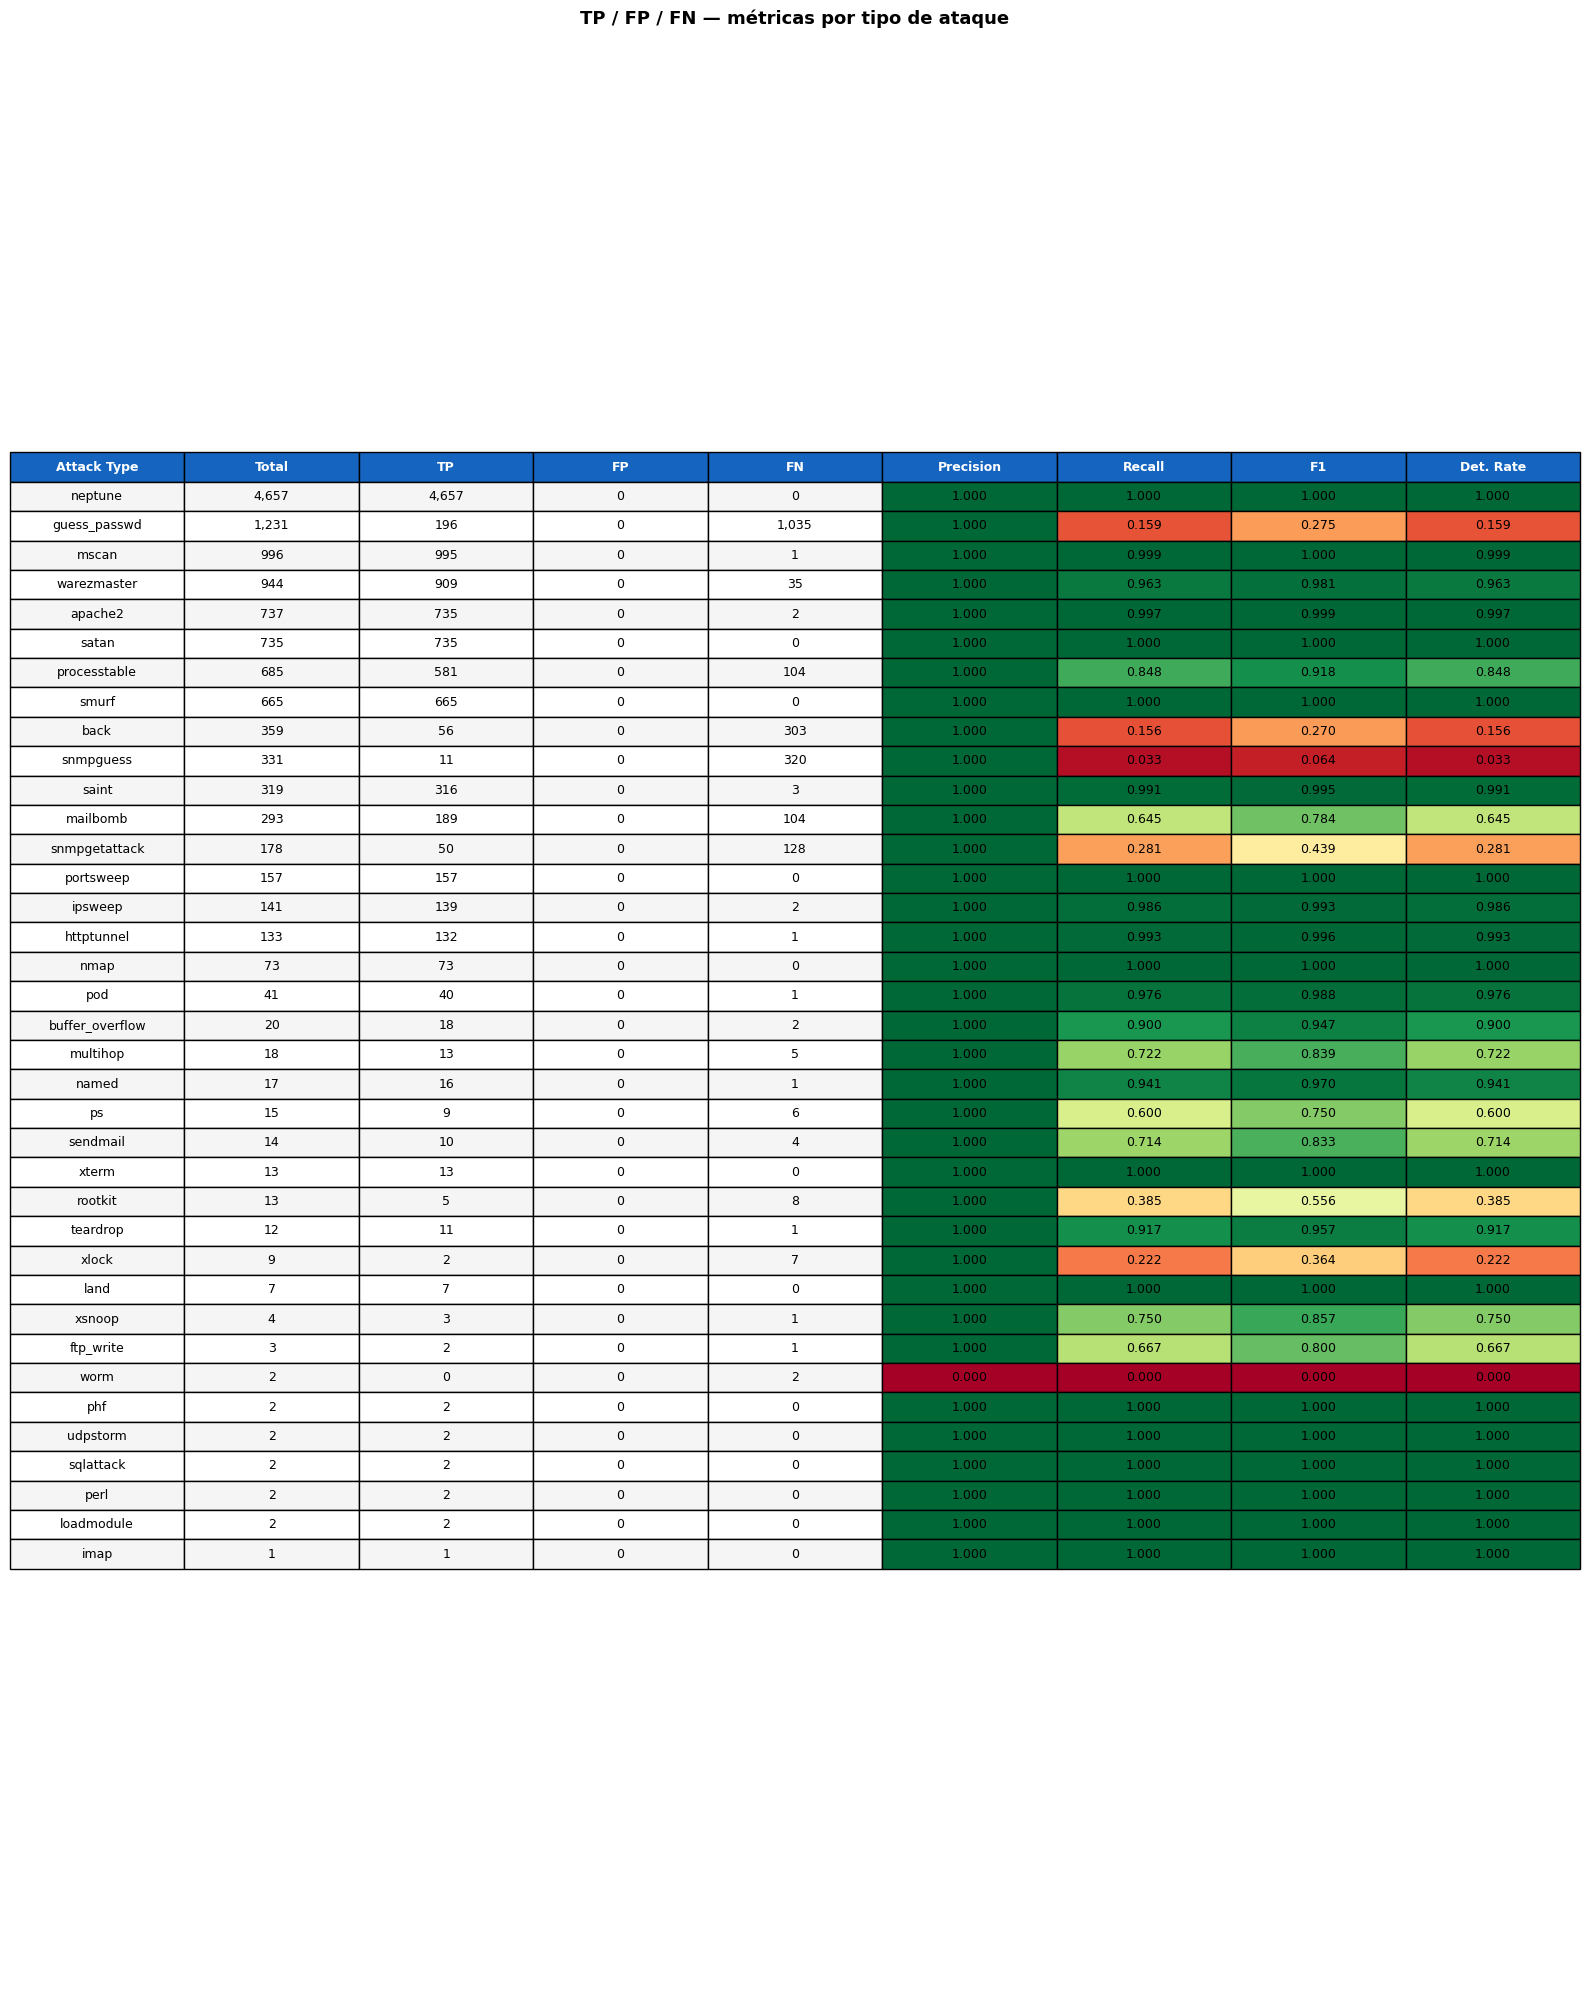

In [ ]:
records = []

for atype in sorted(df["attack_type"].unique()):
    sub = df[df["attack_type"] == atype]

    tp = int(((sub["y_true"] == 1) & (sub["y_pred"] == 1)).sum())
    fp = int(((sub["y_true"] == 0) & (sub["y_pred"] == 1)).sum())
    tn = int(((sub["y_true"] == 0) & (sub["y_pred"] == 0)).sum())
    fn = int(((sub["y_true"] == 1) & (sub["y_pred"] == 0)).sum())

    total = len(sub)
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1    = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    det   = tp / total if total > 0 else 0.0

    records.append({
        "attack_type"   : atype,
        "total"         : total,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"     : round(prec, 4),
        "recall"        : round(rec, 4),
        "f1"            : round(f1, 4),
        "detection_rate": round(det, 4)
    })

stats_df = pd.DataFrame(records).sort_values("total", ascending=False).reset_index(drop=True)
stats_df.to_csv(os.path.join(C50_OUTDIR, "tp_fp_per_attack_type.csv"), index=False)

display_cols = ["attack_type", "total", "tp", "fp", "fn", "precision", "recall", "f1", "detection_rate"]
table_df = stats_df[stats_df["attack_type"] != "normal"][display_cols].copy()

cmap_green = "RdYlGn"

fig, ax = plt.subplots(figsize=(16, len(table_df) * 0.5 + 1.5))
ax.axis("off")

col_labels = ["Attack Type", "Total", "TP", "FP", "FN", "Precision", "Recall", "F1", "Det. Rate"]
cell_text  = []
for _, row in table_df.iterrows():
    cell_text.append([
        row["attack_type"],
        f"{row['total']:,}",
        f"{row['tp']:,}",
        f"{row['fp']:,}",
        f"{row['fn']:,}",
        f"{row['precision']:.3f}",
        f"{row['recall']:.3f}",
        f"{row['f1']:.3f}",
        f"{row['detection_rate']:.3f}",
    ])

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1565c0")
    table[0, j].set_text_props(color="white", fontweight="bold")

metric_cols = {"precision": 5, "recall": 6, "f1": 7, "detection_rate": 8}
import matplotlib.colors as mcolors

for metric, col_idx in metric_cols.items():
    vals = table_df[metric].values
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.get_cmap(cmap_green)
    for row_idx, val in enumerate(vals):
        color = cmap(norm(val))
        table[row_idx + 1, col_idx].set_facecolor(color)

for row_idx in range(len(table_df)):
    bg = "#f5f5f5" if row_idx % 2 == 0 else "white"
    for col_idx in range(5):
        table[row_idx + 1, col_idx].set_facecolor(bg)

plt.title("TP / FP / FN — métricas por tipo de ataque", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(C50_OUTDIR, "metrics_table_per_attack.png"), dpi=150, bbox_inches="tight")
plt.show()